In [1]:
from nba_api.stats.endpoints import synergyplaytypes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
post_up_data_26 = synergyplaytypes.SynergyPlayTypes(
  play_type_nullable= 'Postup',
  player_or_team_abbreviation= 'P',
  season= '2025-26',
  season_type_all_star= 'Regular Season',
  type_grouping_nullable= 'offensive',
  per_mode_simple= 'Totals'
)

post_up_data_25 = synergyplaytypes.SynergyPlayTypes(
  play_type_nullable= 'Postup',
  player_or_team_abbreviation= 'P',
  season= '2024-25',
  season_type_all_star= 'Regular Season',
  type_grouping_nullable= 'offensive',
  per_mode_simple= 'Totals'
)

post_up_data_24 = synergyplaytypes.SynergyPlayTypes(
  play_type_nullable= 'Postup',
  player_or_team_abbreviation= 'P',
  season= '2023-24',
  season_type_all_star= 'Regular Season',
  type_grouping_nullable= 'offensive',
  per_mode_simple= 'Totals'
)

post_up_data_23 = synergyplaytypes.SynergyPlayTypes(
  play_type_nullable= 'Postup',
  player_or_team_abbreviation= 'P',
  season= '2022-23',
  season_type_all_star= 'Regular Season',
  type_grouping_nullable= 'offensive',
  per_mode_simple= 'Totals'
)

ps_26 = post_up_data_26.get_data_frames()[0]
ps_25 = post_up_data_25.get_data_frames()[0]
ps_24 = post_up_data_24.get_data_frames()[0]
ps_23 = post_up_data_23.get_data_frames()[0]

all_postup = pd.concat([ps_26, ps_25, ps_24, ps_23], ignore_index= True)

In [3]:
all_postup_filtered = all_postup[(all_postup['POSS'] > 50)]
all_postup_filtered.sort_values('POSS', ascending= False)

,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,PLAY_TYPE,TYPE_GROUPING,PERCENTILE,GP,...,TOV_POSS_PCT,SF_POSS_PCT,PLUSONE_POSS_PCT,SCORE_POSS_PCT,EFG_PCT,POSS,PTS,FGM,FGA,FGMX
294,22023,203999,Nikola Jokić,1610612743,DEN,Denver Nuggets,Postup,Offensive,0.808,79,...,0.126,0.117,0.034,0.570,0.605,477,542,219,362,143
149,22024,203999,Nikola Jokić,1610612743,DEN,Denver Nuggets,Postup,Offensive,0.757,70,...,0.130,0.117,0.027,0.548,0.581,409,446,179,308,129
446,22022,203999,Nikola Jokić,1610612743,DEN,Denver Nuggets,Postup,Offensive,0.952,69,...,0.156,0.189,0.069,0.600,0.655,360,440,165,252,87
0,22025,203999,Nikola Jokić,1610612743,DEN,Denver Nuggets,Postup,Offensive,0.750,63,...,0.132,0.144,0.029,0.572,0.605,348,393,155,256,101
1,22025,1630578,Alperen Sengun,1610612745,HOU,Houston Rockets,Postup,Offensive,0.459,69,...,0.155,0.107,0.021,0.497,0.548,336,327,136,248,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,22023,1626164,Devin Booker,1610612756,PHX,Phoenix Suns,Postup,Offensive,0.775,67,...,0.115,0.173,0.058,0.538,0.526,52,58,20,38,18
357,22023,1629684,Grant Williams,1610612766,CHA,Charlotte Hornets,Postup,Offensive,0.344,29,...,0.096,0.077,0.019,0.481,0.450,52,47,18,40,22
360,22023,1631105,Jalen Duren,1610612765,DET,Detroit Pistons,Postup,Offensive,0.238,61,...,0.269,0.173,0.038,0.442,0.516,52,46,16,31,15
493,22022,1626164,Devin Booker,1610612756,PHX,Phoenix Suns,Postup,Offensive,0.910,53,...,0.096,0.077,0.038,0.580,0.595,52,62,25,42,17


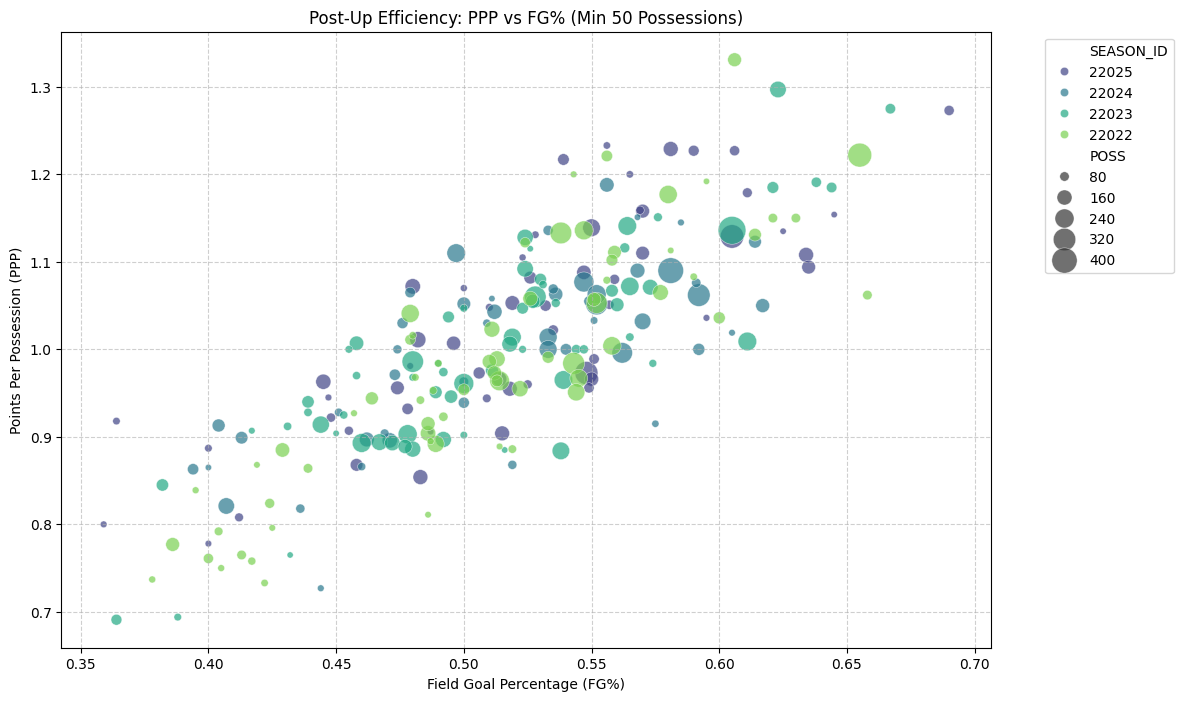

In [4]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=all_postup_filtered, 
    x='FG_PCT', 
    y='PPP', 
    size='POSS', 
    hue='SEASON_ID',
    alpha=0.7, 
    palette='viridis',
    sizes=(20, 400)
)

plt.title('Post-Up Efficiency: PPP vs FG% (Min 50 Possessions)')
plt.xlabel('Field Goal Percentage (FG%)')
plt.ylabel('Points Per Possession (PPP)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

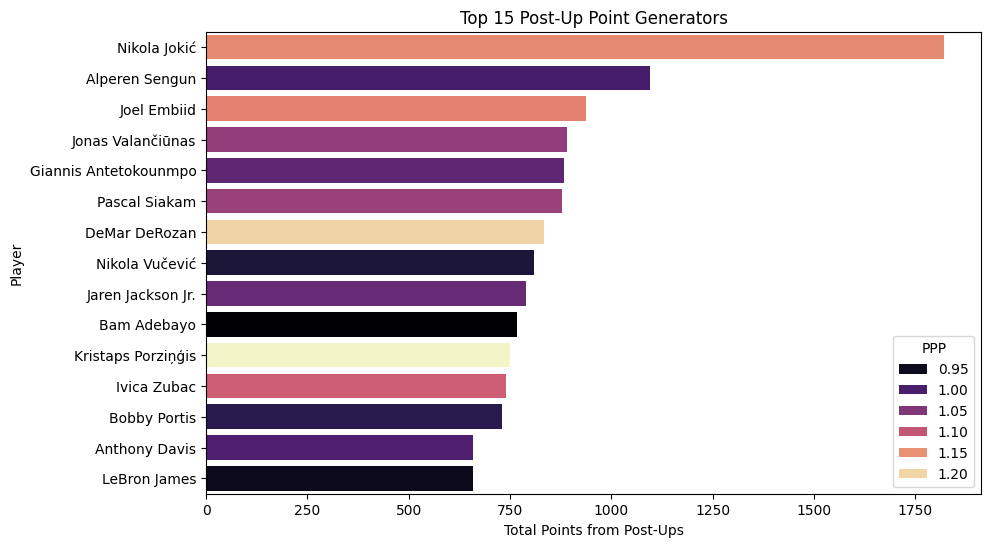

In [5]:
top_scorers = all_postup_filtered.groupby('PLAYER_NAME').agg({
    'PTS': 'sum',
    'PPP': 'mean',
    'POSS': 'sum'
}).sort_values(by='PTS', ascending=False).head(15).reset_index()

plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    data=top_scorers, 
    x='PTS', 
    y='PLAYER_NAME', 
    hue='PPP', 
    palette='magma'
)

plt.title('Top 15 Post-Up Point Generators')
plt.xlabel('Total Points from Post-Ups')
plt.ylabel('Player')
plt.show()

C:\Users\phill\AppData\Local\Temp\ipykernel_7476\1538272370.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_postup_filtered, x='SEASON_ID', y='PPP', palette='Set2')


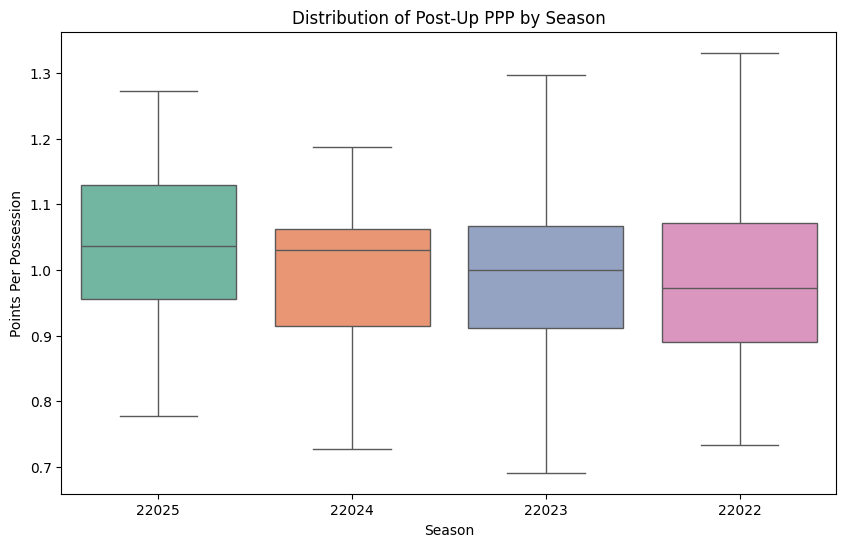

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=all_postup_filtered, x='SEASON_ID', y='PPP', palette='Set2')

plt.title('Distribution of Post-Up PPP by Season')
plt.xlabel('Season')
plt.ylabel('Points Per Possession')
plt.show()

In [7]:
top_ppp = all_postup_filtered.nlargest(10, 'PPP')
top_fg = all_postup_filtered.nlargest(10, 'FG_PCT')

# calculate residuals
m, b = np.polyfit(all_postup_filtered['FG_PCT'], all_postup_filtered['PPP'], 1)
all_postup_filtered['Expected_PPP'] = m * all_postup_filtered['FG_PCT'] + b
all_postup_filtered['Residual'] = (all_postup_filtered['PPP'] - all_postup_filtered['Expected_PPP']).abs()

# outliers
outliers = all_postup_filtered.nlargest(10, 'Residual')

# labels
players_to_label = pd.concat([top_ppp, top_fg, outliers]).drop_duplicates(subset=['PLAYER_NAME'])

In [8]:
print('top ppp')
for player in top_ppp.itertuples():
  print(player.PLAYER_NAME, player.SEASON_ID)

print('top fg')
for player in top_fg.itertuples():
  print(player.PLAYER_NAME, player.SEASON_ID)

print('top outliers')
for player in outliers.itertuples():
  print(player.PLAYER_NAME, player.SEASON_ID)

top ppp
DeMar DeRozan 22022
Kristaps Porziņģis 22023
Ivica Zubac 22023
John Collins 22025
Kristaps Porziņģis 22025
DeMar DeRozan 22025
Kawhi Leonard 22025
Brook Lopez 22025
Nikola Jokić 22022
Jayson Tatum 22022
top fg
John Collins 22025
Ivica Zubac 22023
Rudy Gobert 22022
Nikola Jokić 22022
Jarrett Allen 22025
Rudy Gobert 22023
Shai Gilgeous-Alexander 22023
Jonas Valančiūnas 22025
Giannis Antetokounmpo 22025
Kevin Durant 22022
top outliers
DeMar DeRozan 22022
Jalen Duren 22025
Mikal Bridges 22024
Kristaps Porziņģis 22025
Deandre Ayton 22024
Jayson Tatum 22022
Rudy Gobert 22022
Harrison Barnes 22022
Domantas Sabonis 22023
Naz Reid 22022


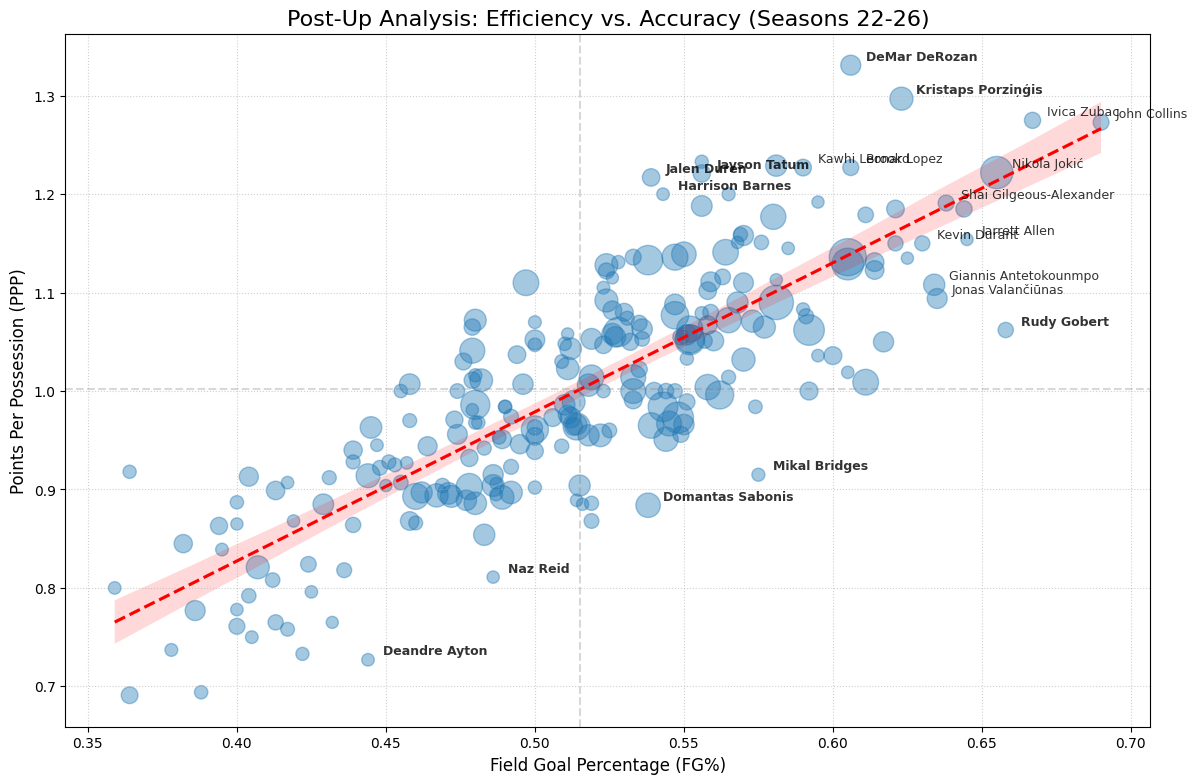

In [9]:
# plot
plt.figure(figsize=(14, 9))
sns.regplot(
    data=all_postup_filtered, 
    x='FG_PCT', 
    y='PPP', 
    scatter_kws={'alpha': 0.4, 's': all_postup_filtered['POSS']*1.5}, 
    line_kws={'color': 'red', 'linestyle': '--', 'label': 'League Average Trend'}
)

# label
for i, row in players_to_label.iterrows():
    plt.text(
        row['FG_PCT'] + 0.005, 
        row['PPP'] + 0.005, 
        row['PLAYER_NAME'], 
        fontsize=9, 
        alpha=0.8,
        fontweight='bold' if row['PLAYER_NAME'] in outliers['PLAYER_NAME'].values else 'normal'
    )

plt.title('Post-Up Analysis: Efficiency vs. Accuracy (Seasons 22-26)', fontsize=16)
plt.xlabel('Field Goal Percentage (FG%)', fontsize=12)
plt.ylabel('Points Per Possession (PPP)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.axvline(all_postup_filtered['FG_PCT'].mean(), color='gray', linestyle='--', alpha=0.3)
plt.axhline(all_postup_filtered['PPP'].mean(), color='gray', linestyle='--', alpha=0.3)

plt.show()

In [10]:
all_postup_filtered.shape


(238, 26)

In [11]:
top_100_ppp = all_postup_filtered.nlargest(100, 'PPP')
print(top_100_ppp['PPP'].mean())

top_100_fg = all_postup_filtered.nlargest(100, 'FG_PCT')
print(top_100_fg['FG_PCT'].mean())

1.11471
0.5753299999999999


In [12]:
top_100_ppp.sort_values('PPP', ascending=False)

,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,PLAY_TYPE,TYPE_GROUPING,PERCENTILE,GP,...,PLUSONE_POSS_PCT,SCORE_POSS_PCT,EFG_PCT,POSS,PTS,FGM,FGA,FGMX,Expected_PPP,Residual
457,22022,201942,DeMar DeRozan,1610612741,CHI,Chicago Bulls,Postup,Offensive,0.976,74,...,0.122,0.640,0.606,139,185,66,109,43,1.139375,0.191625
299,22023,204001,Kristaps Porziņģis,1610612738,BOS,Boston Celtics,Postup,Offensive,0.960,57,...,0.059,0.638,0.623,185,240,76,122,46,1.165123,0.131877
325,22023,1627826,Ivica Zubac,1610612746,LAC,LA Clippers,Postup,Offensive,0.934,68,...,0.022,0.637,0.667,91,116,48,72,24,1.231764,0.043236
23,22025,1628381,John Collins,1610612746,LAC,LA Clippers,Postup,Offensive,0.939,66,...,0.080,0.625,0.690,88,112,49,71,22,1.266600,0.006400
36,22025,204001,Kristaps Porziņģis,1610612737,ATL,Atlanta Hawks,Postup,Offensive,0.912,17,...,0.017,0.633,0.556,60,74,25,45,20,1.063645,0.169355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,22023,203932,Aaron Gordon,1610612743,DEN,Denver Nuggets,Postup,Offensive,0.633,73,...,0.083,0.528,0.494,108,112,39,79,40,0.969741,0.067259
49,22025,1631170,Jaime Jaquez Jr.,1610612748,MIA,Miami Heat,Postup,Offensive,0.581,71,...,0.000,0.545,0.595,55,57,25,42,17,1.122714,0.086714
475,22022,1626174,Christian Wood,1610612742,DAL,Dallas Mavericks,Postup,Offensive,0.659,67,...,0.018,0.550,0.600,112,116,45,75,30,1.130287,0.094287
190,22024,202685,Jonas Valančiūnas,1610612758,SAC,Sacramento Kings,Postup,Offensive,0.583,32,...,0.033,0.525,0.551,61,63,27,49,22,1.056072,0.023072


In [13]:
all_postup_filtered.columns

Index(['SEASON_ID', 'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION',
       'TEAM_NAME', 'PLAY_TYPE', 'TYPE_GROUPING', 'PERCENTILE', 'GP',
       'POSS_PCT', 'PPP', 'FG_PCT', 'FT_POSS_PCT', 'TOV_POSS_PCT',
       'SF_POSS_PCT', 'PLUSONE_POSS_PCT', 'SCORE_POSS_PCT', 'EFG_PCT', 'POSS',
       'PTS', 'FGM', 'FGA', 'FGMX', 'Expected_PPP', 'Residual'],
      dtype='str')

DeMar DeRozan 22022 1.331 0.606 0.64 139
Kristaps Porziņģis 22023 1.297 0.623 0.638 185
Ivica Zubac 22023 1.275 0.667 0.637 91
John Collins 22025 1.273 0.69 0.625 88
Rudy Gobert 22022 1.062 0.658 0.6 81
Nikola Jokić 22022 1.222 0.655 0.6 360
Jarrett Allen 22025 1.154 0.645 0.635 52
Harrison Barnes 22022 1.2 0.543 0.64 55
Alperen Sengun 22025 0.973 0.548 0.497 336


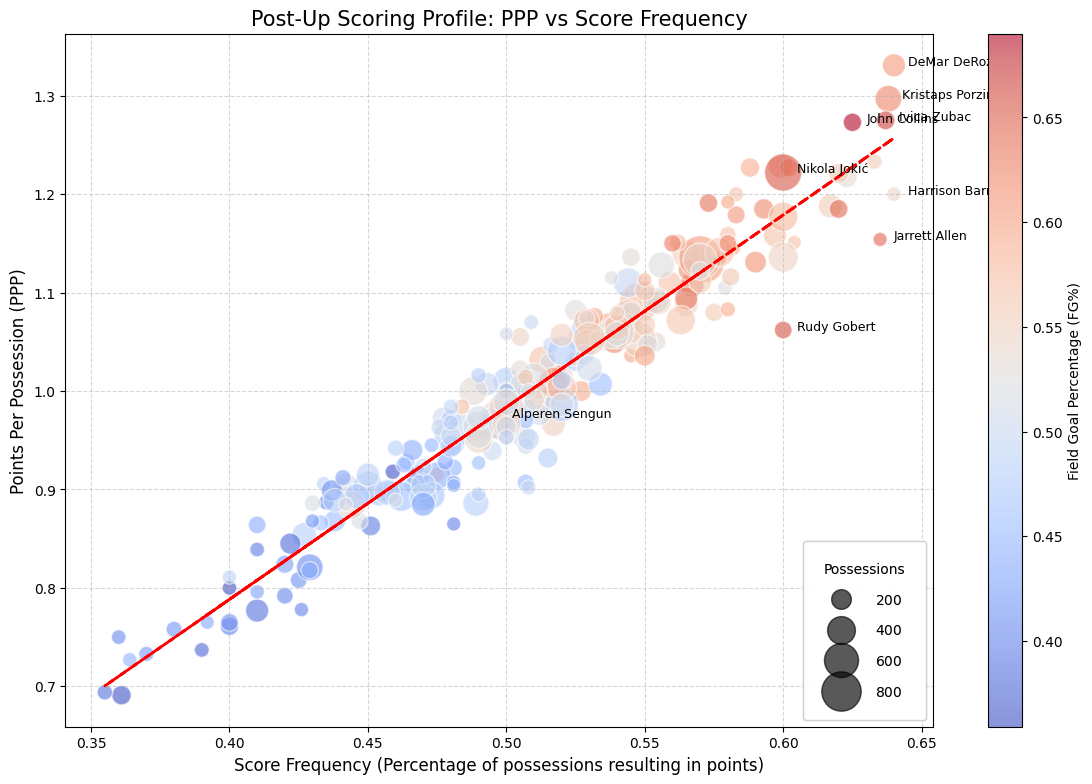

In [19]:
fig, ax = plt.subplots(figsize=(14, 9))
scatter = plt.scatter(
    data=all_postup_filtered,
    x='SCORE_POSS_PCT',
    y='PPP',
    s=all_postup_filtered['POSS'] * 2, # Scale size for visibility
    c='FG_PCT',
    cmap='coolwarm',
    alpha=0.6,
    edgecolors="w"
)

x = all_postup_filtered['SCORE_POSS_PCT']
y = all_postup_filtered['PPP']
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color='red', linestyle='--', linewidth=2, label=f'Trend Line (Slope: {m:.2f})')

top_ppp = all_postup_filtered.nlargest(5, 'PPP')
top_fg = all_postup_filtered.nlargest(5, 'FG_PCT')
top_score_freq = all_postup_filtered.nlargest(5, 'SCORE_POSS_PCT')
top_poss = all_postup_filtered.nlargest(5, 'POSS')

top_labels = pd.concat([top_ppp, top_fg, top_score_freq, top_poss]).drop_duplicates(subset=['PLAYER_NAME'])
for i, row in top_labels.iterrows():
    plt.text(row['SCORE_POSS_PCT']+0.005, row['PPP'], row['PLAYER_NAME'], fontsize=9)
    print(row['PLAYER_NAME'], row['SEASON_ID'], row['PPP'], row['FG_PCT'], row['SCORE_POSS_PCT'], row['POSS'])

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=5)
legend2 = ax.legend(
    handles, 
    labels, 
    loc="lower right", 
    title="Possessions",
    labelspacing=1.2,
    borderpad=1.5,
    handletextpad=1.5
)
ax.add_artist(legend2)

plt.colorbar(scatter, label='Field Goal Percentage (FG%)')
plt.title('Post-Up Scoring Profile: PPP vs Score Frequency', fontsize=15)
plt.xlabel('Score Frequency (Percentage of possessions resulting in points)', fontsize=12)
plt.ylabel('Points Per Possession (PPP)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [15]:
print('top ppp')
for i, row in top_ppp.iterrows():
  print(row['PLAYER_NAME'], row['SEASON_ID'], row['PPP'], row['FG_PCT'], row['SCORE_POSS_PCT'], row['POSS'])

print('top fg')
for i, row in top_fg.iterrows():
  print(row['PLAYER_NAME'], row['SEASON_ID'], row['PPP'], row['FG_PCT'], row['SCORE_POSS_PCT'], row['POSS'])

print('top score fq')
for i, row in top_score_freq.iterrows():
  print(row['PLAYER_NAME'], row['SEASON_ID'], row['PPP'], row['FG_PCT'], row['SCORE_POSS_PCT'], row['POSS'])

print('top poss')
for i, row in top_poss.iterrows():
  print(row['PLAYER_NAME'], row['SEASON_ID'], row['PPP'], row['FG_PCT'], row['SCORE_POSS_PCT'], row['POSS'])

top ppp
DeMar DeRozan 22022 1.331 0.606 0.64 139
Kristaps Porziņģis 22023 1.297 0.623 0.638 185
Ivica Zubac 22023 1.275 0.667 0.637 91
top fg
John Collins 22025 1.273 0.69 0.625 88
Ivica Zubac 22023 1.275 0.667 0.637 91
Rudy Gobert 22022 1.062 0.658 0.6 81
top score fq
DeMar DeRozan 22022 1.331 0.606 0.64 139
Harrison Barnes 22022 1.2 0.543 0.64 55
Kristaps Porziņģis 22023 1.297 0.623 0.638 185
top poss
Nikola Jokić 22023 1.136 0.605 0.57 477
Nikola Jokić 22024 1.09 0.581 0.548 409
Nikola Jokić 22022 1.222 0.655 0.6 360


In [20]:
all_postup_filtered['Expected_PPP'] = m * all_postup_filtered['SCORE_POSS_PCT'] + b
all_postup_filtered['Residual'] = (all_postup_filtered['PPP'] - all_postup_filtered['Expected_PPP']).abs()

# outliers
outliers = all_postup_filtered.nlargest(10, 'Residual')

print('top poss')
for i, row in outliers.iterrows():
  print(row['PLAYER_NAME'], row['SEASON_ID'], row['PPP'], row['FG_PCT'], row['SCORE_POSS_PCT'], row['POSS'])

top poss
Rudy Gobert 22022 1.062 0.658 0.6 81
Isaiah Stewart 22023 0.902 0.5 0.508 61
Jarrett Allen 22025 1.154 0.645 0.635 52
Jock Landale 22025 0.907 0.455 0.507 75
Jonathan Kuminga 22024 0.865 0.4 0.481 52
Zion Williamson 22025 0.932 0.478 0.515 103
Jusuf Nurkić 22023 0.886 0.48 0.489 176
Jamal Murray 22024 1.058 0.511 0.5 52
DeMar DeRozan 22022 1.331 0.606 0.64 139
Kawhi Leonard 22025 1.227 0.59 0.588 97


Rudy Gobert 22022 1.062 0.658 0.6 81
Isaiah Stewart 22023 0.902 0.5 0.508 61
Jarrett Allen 22025 1.154 0.645 0.635 52
Jock Landale 22025 0.907 0.455 0.507 75
Jonathan Kuminga 22024 0.865 0.4 0.481 52
Zion Williamson 22025 0.932 0.478 0.515 103
Jusuf Nurkić 22023 0.886 0.48 0.489 176
Jamal Murray 22024 1.058 0.511 0.5 52
DeMar DeRozan 22022 1.331 0.606 0.64 139
Kawhi Leonard 22025 1.227 0.59 0.588 97


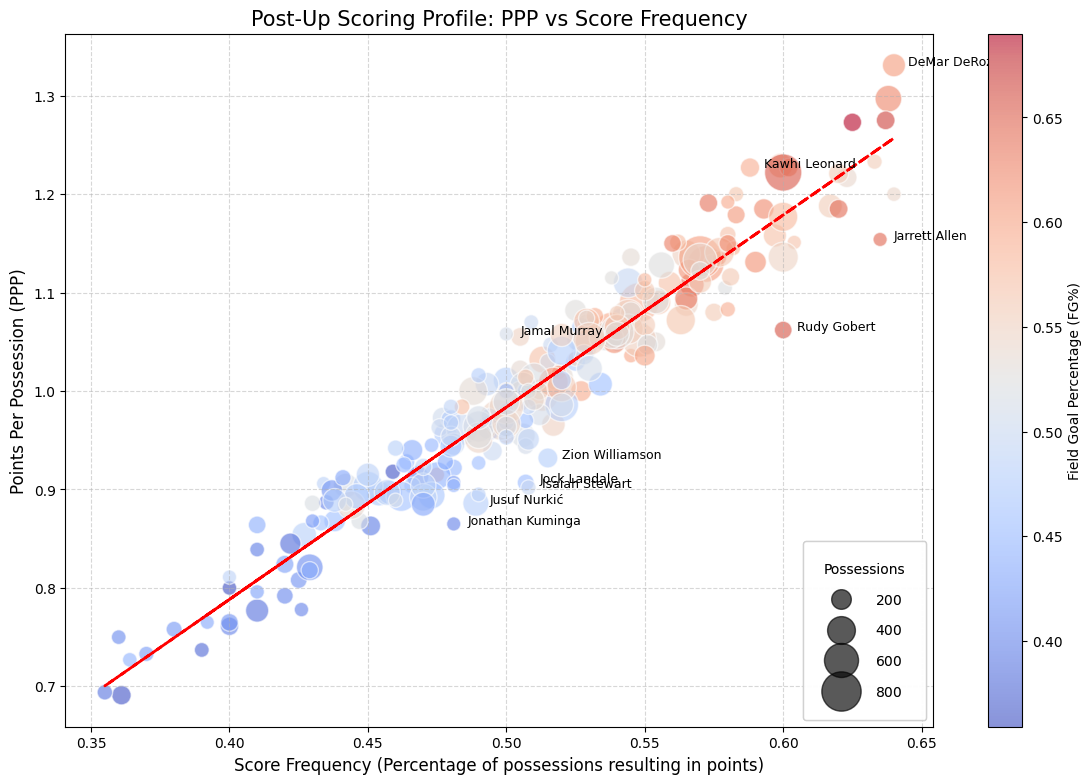

In [21]:
fig, ax = plt.subplots(figsize=(14, 9))
scatter = plt.scatter(
    data=all_postup_filtered,
    x='SCORE_POSS_PCT',
    y='PPP',
    s=all_postup_filtered['POSS'] * 2, # Scale size for visibility
    c='FG_PCT',
    cmap='coolwarm',
    alpha=0.6,
    edgecolors="w"
)

x = all_postup_filtered['SCORE_POSS_PCT']
y = all_postup_filtered['PPP']
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color='red', linestyle='--', linewidth=2, label=f'Trend Line (Slope: {m:.2f})')

top_labels = outliers
for i, row in top_labels.iterrows():
    plt.text(row['SCORE_POSS_PCT']+0.005, row['PPP'], row['PLAYER_NAME'], fontsize=9)
    print(row['PLAYER_NAME'], row['SEASON_ID'], row['PPP'], row['FG_PCT'], row['SCORE_POSS_PCT'], row['POSS'])

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=5)
legend2 = ax.legend(
    handles, 
    labels, 
    loc="lower right", 
    title="Possessions",
    labelspacing=1.2,
    borderpad=1.5,
    handletextpad=1.5
)
ax.add_artist(legend2)

plt.colorbar(scatter, label='Field Goal Percentage (FG%)')
plt.title('Post-Up Scoring Profile: PPP vs Score Frequency', fontsize=15)
plt.xlabel('Score Frequency (Percentage of possessions resulting in points)', fontsize=12)
plt.ylabel('Points Per Possession (PPP)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

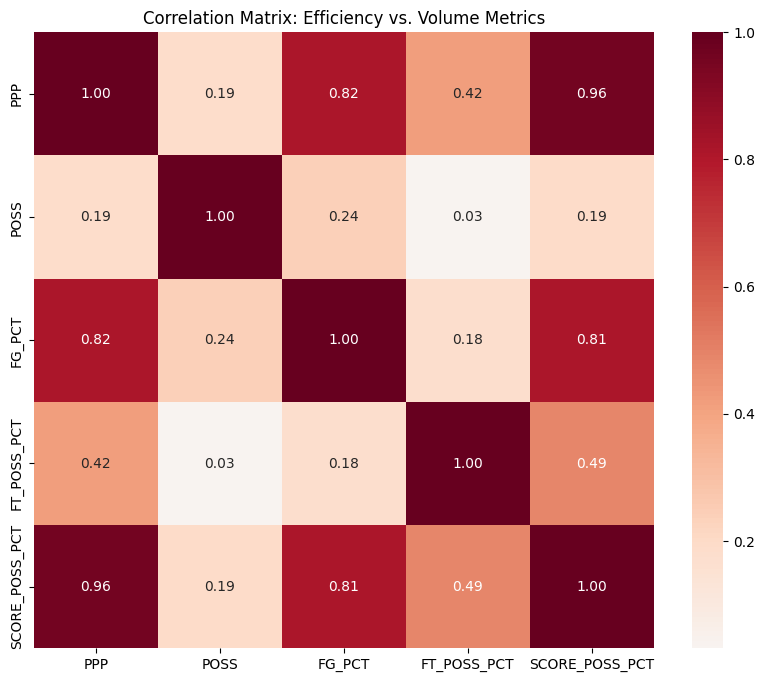

In [17]:
metrics = ['PPP', 'POSS', 'FG_PCT', 'FT_POSS_PCT', 'SCORE_POSS_PCT']
corr_matrix = all_postup_filtered[metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation Matrix: Efficiency vs. Volume Metrics')
plt.show()